<a href="https://colab.research.google.com/github/williamfaraday123/SC4003-Intelligent-Agents/blob/main/assignment_1/graph_plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plot of optimal policy for policy iteration

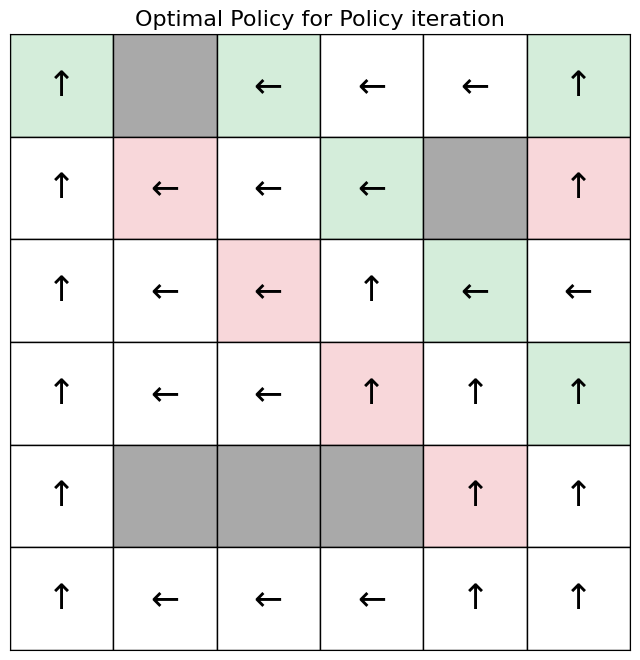

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/policy_iteration.csv")

last_row = df.iloc[-1]

# Create a dictionary mapping (x, y) tuples to their final utility value
# This handles the string column names like '(0, 0)'
utility_dict = {eval(col): val for col, val in last_row.items()}

# 2. Environment Constants from Assignment [cite: 25, 27, 31]
gamma = 0.99
grid_size = 6
walls = [(1, 0), (4, 1), (1, 4), (2, 4), (3, 4)]
rewards = {
    "green": [(0,0), (2,0), (5,0), (3,1), (4,2), (5,3)],
    "brown": [(1,1), (5,1), (2,2), (3,3), (4,4)]
}

def get_utility(x, y):
    """Returns utility from dict; if wall or out of bounds, returns current state utility."""
    if (x, y) in walls or x < 0 or x >= grid_size or y < 0 or y >= grid_size:
        return None # Used to trigger 'stay in place' logic
    return utility_dict.get((x, y), 0)

def find_best_direction(x, y):
    """Calculates max expected utility for UP, DOWN, LEFT, RIGHT."""
    if (x, y) in walls: return ""

    # Possible moves and their perpendiculars (Intended: [Left-angle, Right-angle])
    moves = {
        '↑': {'dest': (x, y-1), 'perp': [(x-1, y), (x+1, y)]},
        '↓': {'dest': (x, y+1), 'perp': [(x-1, y), (x+1, y)]},
        '←': {'dest': (x-1, y), 'perp': [(x, y-1), (x, y+1)]},
        '→': {'dest': (x+1, y), 'perp': [(x, y-1), (x, y+1)]}
    }

    best_action = ""
    max_expected_u = -float('inf')
    current_u = utility_dict[(x, y)]

    for arrow, paths in moves.items():
        # 80% intended direction
        dest_u = get_utility(*paths['dest'])
        expected = 0.8 * (dest_u if dest_u is not None else current_u)

        # 10% for each perpendicular direction
        for perp_coords in paths['perp']:
            perp_u = get_utility(*perp_coords)
            expected += 0.1 * (perp_u if perp_u is not None else current_u)

        if expected > max_expected_u:
            max_expected_u = expected
            best_action = arrow

    return best_action

# 3. Plotting logic
fig, ax = plt.subplots(figsize=(8, 8))

for y in range(grid_size):
    for x in range(grid_size):
        # Determine background color based on reward types [cite: 27]
        face_color = 'white'
        if (x, y) in walls: face_color = '#a9a9a9' # Grey
        elif (x, y) in rewards["green"]: face_color = '#d4edda' # Light Green
        elif (x, y) in rewards["brown"]: face_color = '#f8d7da' # Light Brown/Red

        # Draw cell
        rect = plt.Rectangle((x, grid_size-1-y), 1, 1, facecolor=face_color, edgecolor='black')
        ax.add_patch(rect)

        # Add Arrow if not a wall
        if (x, y) not in walls:
            arrow = find_best_direction(x, y)
            ax.text(x + 0.5, grid_size-1-y + 0.5, arrow, ha='center', va='center', fontsize=25)

# Axis formatting
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_xticks([])
ax.set_yticks([])
plt.title("Optimal Policy for Policy iteration", fontsize=16)
plt.show()

# Utilities of all states for Policy Iteration

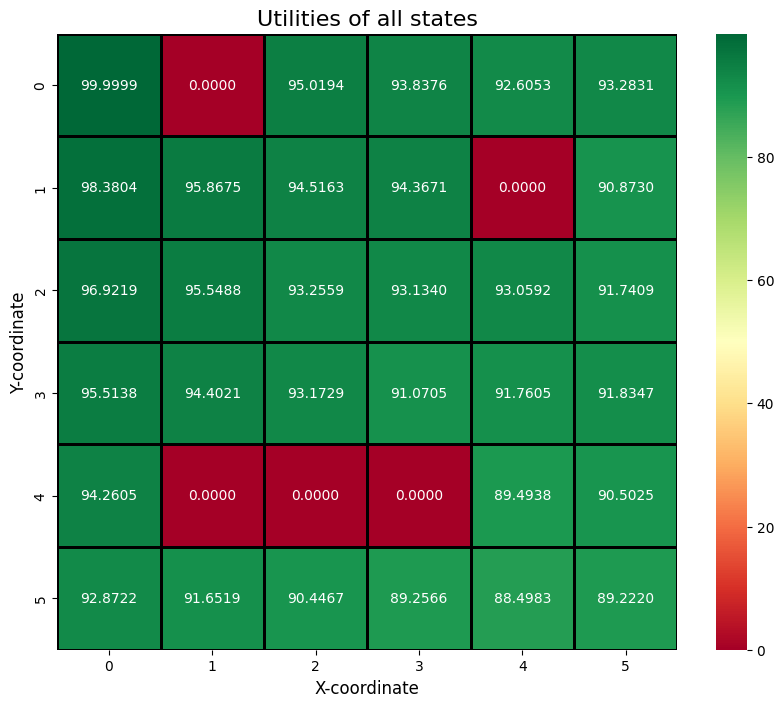

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/policy_iteration.csv")

# 2. Get the last row (utilities)
# Assumes columns are named like '(0, 0)', '(1, 0)', etc.
final_utilities = df.iloc[-1].values

# 3. Reshape the 36 states into a 6x6 grid
# Note: Ensure your CSV column order matches the grid (row by row)
utility_matrix = np.zeros((6, 6))

# Example mapping if your columns are strings of tuples
for col in df.columns:
    # Converting string '(x, y)' to tuple integers
    coords = eval(col)
    x, y = coords
    # Note: In array indexing, row=y and col=x
    utility_matrix[y][x] = df[col].iloc[-1]

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(utility_matrix, annot=True, fmt=".4f", cmap="RdYlGn",
            linewidths=1, linecolor='black', cbar=True)

plt.title("Utilities of all states", fontsize=16)
plt.xlabel("X-coordinate", fontsize=12)
plt.ylabel("Y-coordinate", fontsize=12)

plt.show()

# Policy iteration graph

/tmp/ipykernel_5674/869878407.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(df.columns))


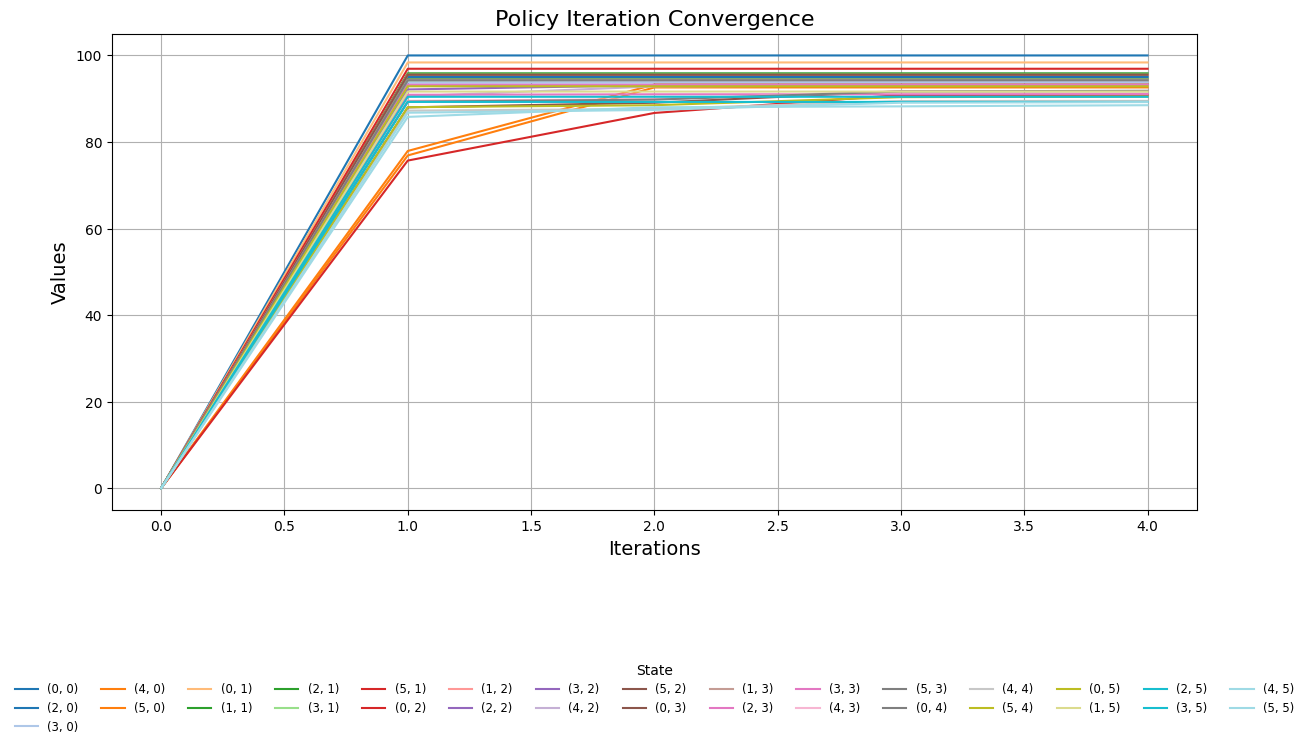

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/policy_iteration.csv")

# Remove the first column which just seems to be an index
df = df.iloc[:, :]

# Define a color palette with enough distinct colors
colors = plt.cm.get_cmap('tab20', len(df.columns))

# Set the figure size
plt.figure(figsize=(14, 7))

# Plot each column with a distinct color from the palette
for i, column in enumerate(df.columns):
    plt.plot(df[column], label=column, color=colors(i))

# Set the title and label the axes
plt.title('Policy Iteration Convergence', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Values', fontsize=14)

# Place the legend at the bottom, display it horizontally, and remove the frame
# Ensure that the number of columns in the legend allows it to display properly
# If the legend still doesn't show up, try reducing the `fontsize` or increasing `ncol`
plt.legend(title='State', bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=len(df.columns)//2, fontsize='small', frameon=False)

# Enable grid for better readability
plt.grid(True)

# Adjust the layout to prevent the legend from being cut off
plt.subplots_adjust(bottom=0.2)

# Display the plot
plt.show()

# Plot of optimal policy for value iteration

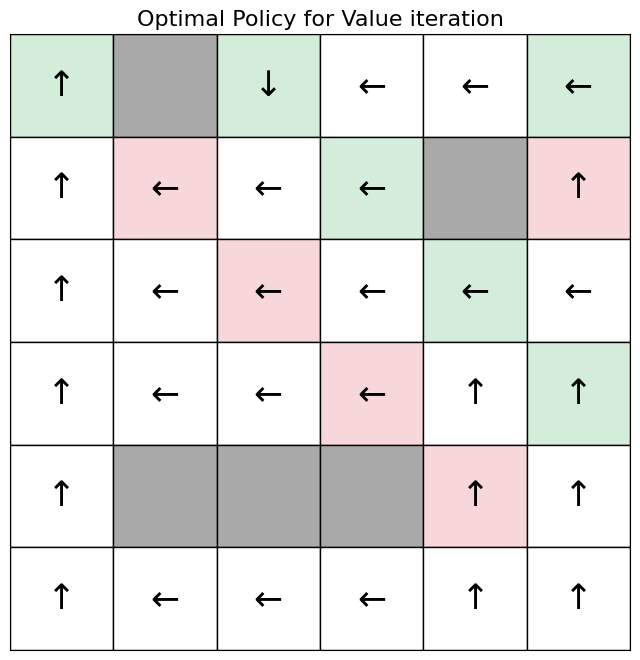

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/value_iteration.csv")

last_row = df.iloc[-1]

# Create a dictionary mapping (x, y) tuples to their final utility value
# This handles the string column names like '(0, 0)'
utility_dict = {eval(col): val for col, val in last_row.items()}

# 2. Environment Constants from Assignment [cite: 25, 27, 31]
gamma = 0.99
grid_size = 6
walls = [(1, 0), (4, 1), (1, 4), (2, 4), (3, 4)]
rewards = {
    "green": [(0,0), (2,0), (5,0), (3,1), (4,2), (5,3)],
    "brown": [(1,1), (5,1), (2,2), (3,3), (4,4)]
}

def get_utility(x, y):
    """Returns utility from dict; if wall or out of bounds, returns current state utility."""
    if (x, y) in walls or x < 0 or x >= grid_size or y < 0 or y >= grid_size:
        return None # Used to trigger 'stay in place' logic
    return utility_dict.get((x, y), 0)

def find_best_direction(x, y):
    """Calculates max expected utility for UP, DOWN, LEFT, RIGHT."""
    if (x, y) in walls: return ""

    # Possible moves and their perpendiculars (Intended: [Left-angle, Right-angle])
    moves = {
        '↑': {'dest': (x, y-1), 'perp': [(x-1, y), (x+1, y)]},
        '↓': {'dest': (x, y+1), 'perp': [(x-1, y), (x+1, y)]},
        '←': {'dest': (x-1, y), 'perp': [(x, y-1), (x, y+1)]},
        '→': {'dest': (x+1, y), 'perp': [(x, y-1), (x, y+1)]}
    }

    best_action = ""
    max_expected_u = -float('inf')
    current_u = utility_dict[(x, y)]

    for arrow, paths in moves.items():
        # 80% intended direction
        dest_u = get_utility(*paths['dest'])
        expected = 0.8 * (dest_u if dest_u is not None else current_u)

        # 10% for each perpendicular direction
        for perp_coords in paths['perp']:
            perp_u = get_utility(*perp_coords)
            expected += 0.1 * (perp_u if perp_u is not None else current_u)

        if expected > max_expected_u:
            max_expected_u = expected
            best_action = arrow

    return best_action

# 3. Plotting logic
fig, ax = plt.subplots(figsize=(8, 8))

for y in range(grid_size):
    for x in range(grid_size):
        # Determine background color based on reward types [cite: 27]
        face_color = 'white'
        if (x, y) in walls: face_color = '#a9a9a9' # Grey
        elif (x, y) in rewards["green"]: face_color = '#d4edda' # Light Green
        elif (x, y) in rewards["brown"]: face_color = '#f8d7da' # Light Brown/Red

        # Draw cell
        rect = plt.Rectangle((x, grid_size-1-y), 1, 1, facecolor=face_color, edgecolor='black')
        ax.add_patch(rect)

        # Add Arrow if not a wall
        if (x, y) not in walls:
            arrow = find_best_direction(x, y)
            ax.text(x + 0.5, grid_size-1-y + 0.5, arrow, ha='center', va='center', fontsize=25)

# Axis formatting
ax.set_xlim(0, grid_size)
ax.set_ylim(0, grid_size)
ax.set_xticks([])
ax.set_yticks([])
plt.title("Optimal Policy for Value iteration", fontsize=16)
plt.show()

# Utilities of all states for value iteration

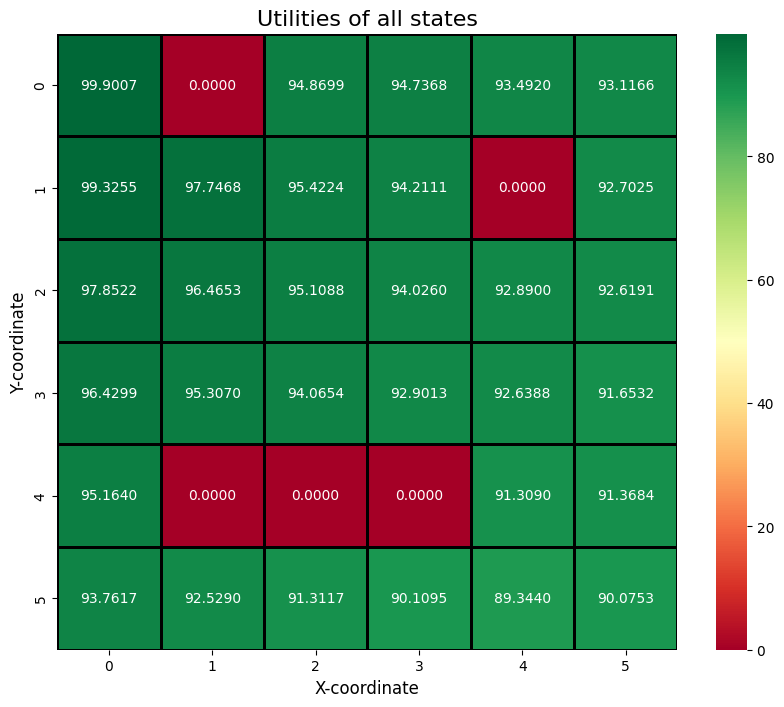

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Load data
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/value_iteration.csv")

# 2. Get the last row (utilities)
# Assumes columns are named like '(0, 0)', '(1, 0)', etc.
final_utilities = df.iloc[-1].values

# 3. Reshape the 36 states into a 6x6 grid
# Note: Ensure your CSV column order matches the grid (row by row)
utility_matrix = np.zeros((6, 6))

# mapping if columns are strings of tuples
for col in df.columns:
    # Converting string '(x, y)' to tuple integers
    coords = eval(col)
    x, y = coords
    # Note: In array indexing, row=y and col=x
    utility_matrix[y][x] = df[col].iloc[-1]

# 4. Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(utility_matrix, annot=True, fmt=".4f", cmap="RdYlGn",
            linewidths=1, linecolor='black', cbar=True)

plt.title("Utilities of all states", fontsize=16)
plt.xlabel("X-coordinate", fontsize=12)
plt.ylabel("Y-coordinate", fontsize=12)

plt.show()

# Value Iteration graph

/tmp/ipykernel_5674/3995532479.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(df.columns))


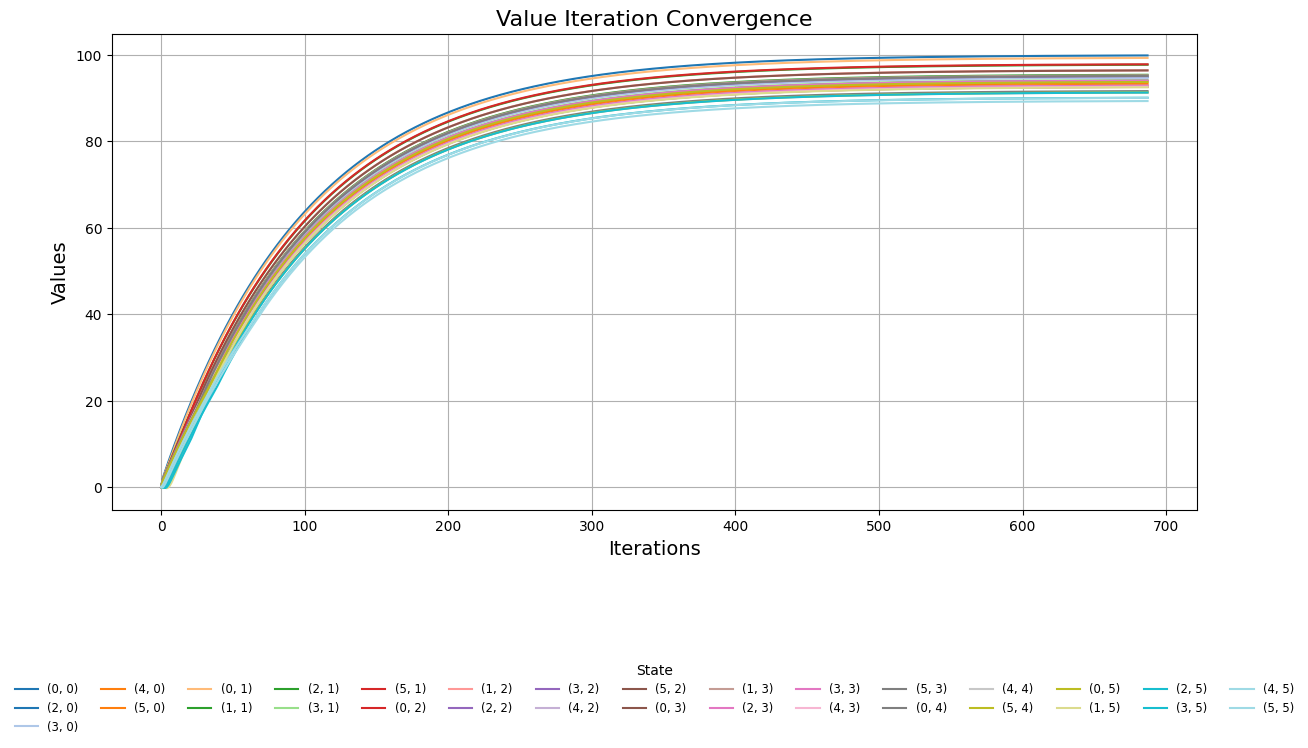

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file
df = pd.read_csv(r"https://raw.githubusercontent.com/williamfaraday123/SC4003-Intelligent-Agents/refs/heads/main/assignment_1/value_iteration.csv")

# Remove the first column which just seems to be an index
df = df.iloc[:, :]

# Define a color palette with enough distinct colors
colors = plt.cm.get_cmap('tab20', len(df.columns))

# Set the figure size
plt.figure(figsize=(14, 7))

# Plot each column with a distinct color from the palette
for i, column in enumerate(df.columns):
    plt.plot(df[column], label=column, color=colors(i))

# Set the title and label the axes
plt.title('Value Iteration Convergence', fontsize=16)
plt.xlabel('Iterations', fontsize=14)
plt.ylabel('Values', fontsize=14)

# Place the legend at the bottom, display it horizontally, and remove the frame
# Ensure that the number of columns in the legend allows it to display properly
# If the legend still doesn't show up, try reducing the `fontsize` or increasing `ncol`
plt.legend(title='State', bbox_to_anchor=(0.5, -0.3), loc='upper center', ncol=len(df.columns)//2, fontsize='small', frameon=False)

# Enable grid for better readability
plt.grid(True)

# Adjust the layout to prevent the legend from being cut off
plt.subplots_adjust(bottom=0.2)

# Display the plot
plt.show()